In [ ]:
import pandas as pd

# Google Drive Direct Download Link
url = "https://drive.google.com/uc?id=1LRz3lh6SO53VeVPz5u9TLBBXyuslRQVQ"

spotify_df = pd.read_csv(url)

spotify_df.head()

,Unnamed: 0,name,artist,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,type,duration_ms,time_signature,id,html
0,0,Se Eu Quiser Falar Com Deus ...,Gilberto Gil,0.658,0.2590,11,-13.141,0,0.0705,0.694,0.000059,0.975,0.306,110.376,,256213,4,1n7JnwviZ7zf0LR1tcGFq7,https://open.spotify.com/track/1n7JnwviZ7zf0LR...
1,1,Saudade De Bahia ...,Antônio Carlos Jobim,0.742,0.3990,2,-12.646,1,0.0346,0.217,0.000002,0.107,0.693,125.039,,191867,4,5QGM1U0eCYrQuwSJwTm5Zq,https://open.spotify.com/track/5QGM1U0eCYrQuwS...
2,2,"Canta Canta, Minha Gente ...",Martinho Da Vila,0.851,0.7300,2,-11.048,1,0.3470,0.453,0.000063,0.124,0.905,93.698,,152267,4,0NLIFSZxPzQhCwnkn5PJYs,https://open.spotify.com/track/0NLIFSZxPzQhCwn...
3,3,Mulher Eu Sei ...,Chico César,0.705,0.0502,4,-18.115,1,0.0471,0.879,0.000041,0.386,0.524,106.802,,186227,4,3mXqOdlLE1k67WsAxryPFs,https://open.spotify.com/track/3mXqOdlLE1k67Ws...
4,4,Rosa Morena ...,Kurt Elling,0.651,0.1190,6,-19.807,1,0.0380,0.916,0.000343,0.104,0.402,120.941,,273680,4,7bSzjzjTkWT2CkIPPdp0eA,https://open.spotify.com/track/7bSzjzjTkWT2CkI...


In [ ]:
# only keep numeric columns
spotify_numeric = spotify_df.select_dtypes(include=["number"])

# delete space in column names
spotify_numeric.columns = spotify_numeric.columns.str.strip()

# drop columns
to_drop = ['key', 'mode', 'duration_ms', 'time_signature']
spotify_numeric = spotify_numeric.drop(columns=to_drop, errors="ignore")

spotify_numeric.head()

,Unnamed: 0,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo
0,0,0.658,0.2590,-13.141,0.0705,0.694,0.000059,0.975,0.306,110.376
1,1,0.742,0.3990,-12.646,0.0346,0.217,0.000002,0.107,0.693,125.039
2,2,0.851,0.7300,-11.048,0.3470,0.453,0.000063,0.124,0.905,93.698
3,3,0.705,0.0502,-18.115,0.0471,0.879,0.000041,0.386,0.524,106.802
4,4,0.651,0.1190,-19.807,0.0380,0.916,0.000343,0.104,0.402,120.941


In [ ]:
# put all features on the same scale
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

scaled_spotify = scaler.fit_transform(spotify_numeric)

# check if its between 0 and 1
scaled_df = pd.DataFrame(scaled_spotify, columns=spotify_numeric.columns)
scaled_df.head()

,Unnamed: 0,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo
0,0.000000,0.680455,0.2590,0.763897,0.076797,0.696787,0.000060,0.987842,0.310660,0.515800
1,0.000191,0.767322,0.3990,0.771967,0.037691,0.217871,0.000002,0.108409,0.703553,0.584322
2,0.000382,0.880041,0.7300,0.798018,0.377996,0.454819,0.000064,0.125633,0.918782,0.437862
3,0.000573,0.729059,0.0502,0.682811,0.051307,0.882530,0.000041,0.391084,0.531980,0.499098
4,0.000764,0.673216,0.1190,0.655228,0.041394,0.919679,0.000348,0.105370,0.408122,0.565171


In [ ]:
# put features into PC groups, E.G: PC1, PC2, etc. PC1 has the biggest difference between songs, PC2 the second biggest etc
from sklearn.decomposition import PCA

pca = PCA()

pca.fit(scaled_spotify)

explained_variance = pca.explained_variance_ratio_

explained_variance

array([0.3914476 , 0.30456331, 0.10050896, 0.0739088 , 0.03919105,
       0.03203065, 0.02524178, 0.02110391, 0.00844173, 0.0035622 ])

In [ ]:
# Add every new Principal component to the prior ones, so first Value is PC1, second PC1 + PC2, and so on
import numpy as np

cumulative_variance = np.cumsum(explained_variance)

cumulative_variance

array([0.3914476 , 0.69601091, 0.79651987, 0.87042867, 0.90961972,
       0.94165038, 0.96689216, 0.98799607, 0.9964378 , 1.        ])

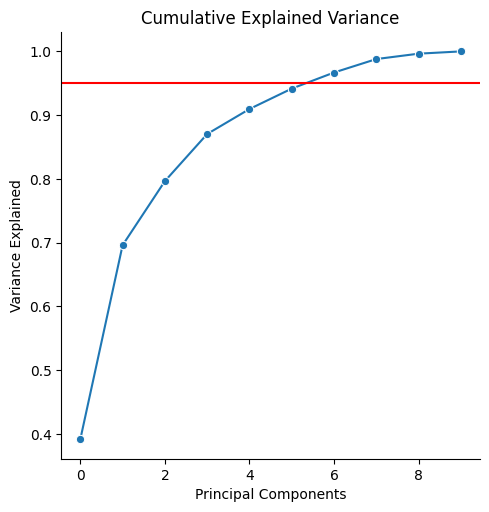

In [ ]:
# check, how many Principal components i need for how much of the Variance(her the desired number is 0.95), and what can be cut off as noise
import seaborn as sns
import matplotlib.pyplot as plt

sns.relplot(
    kind="line",
    x=range(len(explained_variance)),
    y=cumulative_variance,
    marker="o"
)

plt.axhline(y=0.95, color="red")
plt.title("Cumulative Explained Variance")
plt.xlabel("Principal Components")
plt.ylabel("Variance Explained")

plt.show()

In [ ]:
# take only the Principal components that are inside the desired number (will take as much Principal components that at least in this case 0.95 of variance is explained)
pca_final = PCA(n_components=0.95)

spotify_pca = pca_final.fit_transform(scaled_spotify)

spotify_pca_df = pd.DataFrame(spotify_pca)

spotify_pca_df.head()

,0,1,2,3,4,5,6
0,0.177069,0.683928,0.044970,-0.354709,0.525634,0.618396,0.180635
1,-0.265274,0.553102,-0.236076,-0.113907,-0.185021,0.053049,0.090586
2,-0.390014,0.624921,-0.324164,0.066144,-0.009611,0.034002,-0.146036
3,0.303052,0.978015,0.015634,-0.129401,0.102813,0.230829,0.082600
4,0.365051,0.926022,0.047120,-0.217546,-0.087636,0.021548,0.081048


In [ ]:
# create clusters(groups) with songs in each cluster that have similar values in all Principal components
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=5, random_state=42)

clusters = kmeans.fit_predict(spotify_pca_df)

spotify_pca_df["cluster"] = clusters

spotify_pca_df.head()

,0,1,2,3,4,5,6,cluster
0,0.177069,0.683928,0.044970,-0.354709,0.525634,0.618396,0.180635,4
1,-0.265274,0.553102,-0.236076,-0.113907,-0.185021,0.053049,0.090586,2
2,-0.390014,0.624921,-0.324164,0.066144,-0.009611,0.034002,-0.146036,2
3,0.303052,0.978015,0.015634,-0.129401,0.102813,0.230829,0.082600,4
4,0.365051,0.926022,0.047120,-0.217546,-0.087636,0.021548,0.081048,4


In [ ]:
spotify_df["cluster"] = clusters

spotify_df.groupby("cluster").head(3)

,Unnamed: 0,name,artist,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,type,duration_ms,time_signature,id,html,cluster
0,0,Se Eu Quiser Falar Com Deus ...,Gilberto Gil,0.658,0.2590,11,-13.141,0,0.0705,0.694000,0.000059,0.9750,0.3060,110.376,,256213,4,1n7JnwviZ7zf0LR1tcGFq7,https://open.spotify.com/track/1n7JnwviZ7zf0LR...,4
1,1,Saudade De Bahia ...,Antônio Carlos Jobim,0.742,0.3990,2,-12.646,1,0.0346,0.217000,0.000002,0.1070,0.6930,125.039,,191867,4,5QGM1U0eCYrQuwSJwTm5Zq,https://open.spotify.com/track/5QGM1U0eCYrQuwS...,2
2,2,"Canta Canta, Minha Gente ...",Martinho Da Vila,0.851,0.7300,2,-11.048,1,0.3470,0.453000,0.000063,0.1240,0.9050,93.698,,152267,4,0NLIFSZxPzQhCwnkn5PJYs,https://open.spotify.com/track/0NLIFSZxPzQhCwn...,2
3,3,Mulher Eu Sei ...,Chico César,0.705,0.0502,4,-18.115,1,0.0471,0.879000,0.000041,0.3860,0.5240,106.802,,186227,4,3mXqOdlLE1k67WsAxryPFs,https://open.spotify.com/track/3mXqOdlLE1k67Ws...,4
4,4,Rosa Morena ...,Kurt Elling,0.651,0.1190,6,-19.807,1,0.0380,0.916000,0.000343,0.1040,0.4020,120.941,,273680,4,7bSzjzjTkWT2CkIPPdp0eA,https://open.spotify.com/track/7bSzjzjTkWT2CkI...,4
8,8,Brigas Nunca Mais ...,Paula Morelenbaum,0.694,0.5460,10,-11.452,1,0.0400,0.398000,0.076000,0.1530,0.6410,170.032,,204027,4,1wL2dk42Cxu4zCJs4SvFsZ,https://open.spotify.com/track/1wL2dk42Cxu4zCJ...,2
18,18,Aquarela Do Brasil ...,Carlos Barbosa-Lima,0.423,0.2520,4,-19.264,0,0.0467,0.963000,0.901000,0.1050,0.4380,81.025,,207160,4,3ftxaxht5yQW99vNcibmUC,https://open.spotify.com/track/3ftxaxht5yQW99v...,0
19,19,Brigas Nunca Mais ...,Brazilian Jazz,0.529,0.2760,0,-14.859,1,0.0457,0.972000,0.885000,0.1330,0.2800,96.134,,146800,4,5gvBgfXusUpxjOWHyYJXVg,https://open.spotify.com/track/5gvBgfXusUpxjOW...,0
21,21,Aquarela Do Brasil ...,Voyager,0.449,0.1450,9,-19.732,1,0.0484,0.937000,0.919000,0.0769,0.3040,91.330,,227400,3,3pjbCjL1IlqOfuQ8YOkX6o,https://open.spotify.com/track/3pjbCjL1IlqOfuQ...,0
209,209,La Nueva Reconquista de Graná ...,Grupo De Expertos Solynieve,0.229,0.6400,9,-7.361,1,0.0469,0.413000,0.755000,0.0927,0.5460,166.732,,238186,3,6Oj0gEBy4t8cYNX43u6cXd,https://open.spotify.com/track/6Oj0gEBy4t8cYNX...,3


In [ ]:
spotify_df.columns = spotify_df.columns.str.strip()

In [ ]:
# show whole strings for html
pd.set_option('display.max_colwidth', None)

In [ ]:
# Cluster 0
cluster_0_songs = spotify_df[spotify_df['cluster'] == 0].head(3)
cluster_0_songs[['name', 'artist', 'html'] + list(spotify_numeric.columns)]

,name,artist,html,Unnamed: 0,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo
18,Aquarela Do Brasil,Carlos Barbosa-Lima,https://open.spotify.com/track/3ftxaxht5yQW99vNcibmUC,18,0.423,0.252,-19.264,0.0467,0.963,0.901,0.1050,0.438,81.025
19,Brigas Nunca Mais,Brazilian Jazz,https://open.spotify.com/track/5gvBgfXusUpxjOWHyYJXVg,19,0.529,0.276,-14.859,0.0457,0.972,0.885,0.1330,0.280,96.134
21,Aquarela Do Brasil,Voyager,https://open.spotify.com/track/3pjbCjL1IlqOfuQ8YOkX6o,21,0.449,0.145,-19.732,0.0484,0.937,0.919,0.0769,0.304,91.330


In [ ]:
# Cluster 1
cluster_1_songs = spotify_df[spotify_df['cluster'] == 1].head(3)
cluster_1_songs[['name', 'artist', 'html'] + list(spotify_numeric.columns)]

,name,artist,html,Unnamed: 0,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo
512,All In White,The Vaccines,https://open.spotify.com/track/6nndigGeN6q17URSgwA7ks,512,0.311,0.867,-5.200,0.0800,0.047200,0.000069,0.0943,0.0919,131.230
1289,With Or Without You - Remastered,U2,https://open.spotify.com/track/6ADSaE87h8Y3lccZlBJdXH,1289,0.540,0.429,-11.822,0.0285,0.000202,0.355000,0.1410,0.1130,110.171
1304,Purple Rain,Prince,https://open.spotify.com/track/4m2GdLuOhDt6rFbgOFMHIL,1304,0.383,0.570,-7.019,0.0318,0.041600,0.006830,0.7460,0.1830,114.147


In [ ]:
# Cluster 2
cluster_2_songs = spotify_df[spotify_df['cluster'] == 2].head(3)
cluster_2_songs[['name', 'artist', 'html'] + list(spotify_numeric.columns)]

,name,artist,html,Unnamed: 0,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo
1,Saudade De Bahia,Antônio Carlos Jobim,https://open.spotify.com/track/5QGM1U0eCYrQuwSJwTm5Zq,1,0.742,0.399,-12.646,0.0346,0.217,0.000002,0.107,0.693,125.039
2,"Canta Canta, Minha Gente",Martinho Da Vila,https://open.spotify.com/track/0NLIFSZxPzQhCwnkn5PJYs,2,0.851,0.730,-11.048,0.3470,0.453,0.000063,0.124,0.905,93.698
8,Brigas Nunca Mais,Paula Morelenbaum,https://open.spotify.com/track/1wL2dk42Cxu4zCJs4SvFsZ,8,0.694,0.546,-11.452,0.0400,0.398,0.076000,0.153,0.641,170.032


In [ ]:
# Cluster 3
cluster_3_songs = spotify_df[spotify_df['cluster'] == 3].head(3)
cluster_3_songs[['name', 'artist', 'html'] + list(spotify_numeric.columns)]

,name,artist,html,Unnamed: 0,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo
209,La Nueva Reconquista de Graná,Grupo De Expertos Solynieve,https://open.spotify.com/track/6Oj0gEBy4t8cYNX43u6cXd,209,0.229,0.640,-7.361,0.0469,0.413000,0.755,0.0927,0.546,166.732
224,"Que No Sea Kang, Por Favor",Los Planetas,https://open.spotify.com/track/41OGvdfzThkNxQVUkkWgq9,224,0.435,0.494,-9.032,0.0279,0.000228,0.854,0.1600,0.228,93.997
246,A New Error,Moderat,https://open.spotify.com/track/6OGRM4MAOlyOdhHuX0OJ6P,246,0.719,0.461,-11.338,0.0370,0.029800,0.801,0.0634,0.104,110.991


In [ ]:
# Cluster 4
cluster_4_songs = spotify_df[spotify_df['cluster'] == 4].head(3)
cluster_4_songs[['name', 'artist', 'html'] + list(spotify_numeric.columns)]

,name,artist,html,Unnamed: 0,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo
0,Se Eu Quiser Falar Com Deus,Gilberto Gil,https://open.spotify.com/track/1n7JnwviZ7zf0LR1tcGFq7,0,0.658,0.2590,-13.141,0.0705,0.694,0.000059,0.975,0.306,110.376
3,Mulher Eu Sei,Chico César,https://open.spotify.com/track/3mXqOdlLE1k67WsAxryPFs,3,0.705,0.0502,-18.115,0.0471,0.879,0.000041,0.386,0.524,106.802
4,Rosa Morena,Kurt Elling,https://open.spotify.com/track/7bSzjzjTkWT2CkIPPdp0eA,4,0.651,0.1190,-19.807,0.0380,0.916,0.000343,0.104,0.402,120.941


In [ ]:
# create scaled DataFrame
scaled_df = pd.DataFrame(scaled_spotify, columns=spotify_numeric.columns)

# add cluster-column
scaled_df['cluster'] = clusters

# keep spotify name, artist, html in original DF
spotify_info = spotify_df[['name', 'artist', 'html']].reset_index(drop=True)
scaled_info = pd.concat([spotify_info, scaled_df], axis=1)

# Cluster 0: all features + name/artist/link, alle values scaled
cluster_0_scaled = scaled_info[scaled_info['cluster'] == 0].head(3)
cluster_0_scaled

,name,artist,html,Unnamed: 0,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,cluster
18,Aquarela Do Brasil,Carlos Barbosa-Lima,https://open.spotify.com/track/3ftxaxht5yQW99vNcibmUC,0.003439,0.437435,0.252,0.664080,0.050871,0.966867,0.914721,0.106383,0.444670,0.378639,0
19,Brigas Nunca Mais,Brazilian Jazz,https://open.spotify.com/track/5gvBgfXusUpxjOWHyYJXVg,0.003630,0.547053,0.276,0.735891,0.049782,0.975904,0.898477,0.134752,0.284264,0.449245,0
21,Aquarela Do Brasil,Voyager,https://open.spotify.com/track/3pjbCjL1IlqOfuQ8YOkX6o,0.004012,0.464323,0.145,0.656451,0.052723,0.940763,0.932995,0.077913,0.308629,0.426796,0


In [ ]:
# Cluster 1: all features + name/artist/link, alle values scaled
cluster_1_scaled = scaled_info[scaled_info['cluster'] == 1].head(3)
cluster_1_scaled

,name,artist,html,Unnamed: 0,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,cluster
512,All In White,The Vaccines,https://open.spotify.com/track/6nndigGeN6q17URSgwA7ks,0.097822,0.321613,0.867,0.893352,0.087146,0.047390,0.000070,0.095542,0.093299,0.613253,1
1289,With Or Without You - Remastered,U2,https://open.spotify.com/track/6ADSaE87h8Y3lccZlBJdXH,0.246274,0.558428,0.429,0.785400,0.031046,0.000203,0.360406,0.142857,0.114721,0.514842,1
1304,Purple Rain,Prince,https://open.spotify.com/track/4m2GdLuOhDt6rFbgOFMHIL,0.249140,0.396070,0.570,0.863699,0.034641,0.041767,0.006934,0.755826,0.185787,0.533422,1


In [ ]:
# Cluster 2
cluster_2_scaled = scaled_info[scaled_info['cluster'] == 2].head(3)
cluster_2_scaled

,name,artist,html,Unnamed: 0,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,cluster
1,Saudade De Bahia,Antônio Carlos Jobim,https://open.spotify.com/track/5QGM1U0eCYrQuwSJwTm5Zq,0.000191,0.767322,0.399,0.771967,0.037691,0.217871,0.000002,0.108409,0.703553,0.584322,2
2,"Canta Canta, Minha Gente",Martinho Da Vila,https://open.spotify.com/track/0NLIFSZxPzQhCwnkn5PJYs,0.000382,0.880041,0.730,0.798018,0.377996,0.454819,0.000064,0.125633,0.918782,0.437862,2
8,Brigas Nunca Mais,Paula Morelenbaum,https://open.spotify.com/track/1wL2dk42Cxu4zCJs4SvFsZ,0.001528,0.717684,0.546,0.791432,0.043573,0.399598,0.077157,0.155015,0.650761,0.794579,2


In [ ]:
# Cluster 3
cluster_3_scaled = scaled_info[scaled_info['cluster'] == 3].head(3)
cluster_3_scaled

,name,artist,html,Unnamed: 0,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,cluster
209,La Nueva Reconquista de Graná,Grupo De Expertos Solynieve,https://open.spotify.com/track/6Oj0gEBy4t8cYNX43u6cXd,0.039931,0.236815,0.640,0.858123,0.051089,0.414659,0.766497,0.093921,0.554315,0.779158,3
224,"Que No Sea Kang, Por Favor",Los Planetas,https://open.spotify.com/track/41OGvdfzThkNxQVUkkWgq9,0.042797,0.449845,0.494,0.830883,0.030392,0.000229,0.867005,0.162107,0.231472,0.439259,3
246,A New Error,Moderat,https://open.spotify.com/track/6OGRM4MAOlyOdhHuX0OJ6P,0.047000,0.743537,0.461,0.793290,0.040305,0.029920,0.813198,0.064235,0.105584,0.518674,3


In [ ]:
# Cluster 4
cluster_4_scaled = scaled_info[scaled_info['cluster'] == 4].head(3)
cluster_4_scaled

,name,artist,html,Unnamed: 0,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,cluster
0,Se Eu Quiser Falar Com Deus,Gilberto Gil,https://open.spotify.com/track/1n7JnwviZ7zf0LR1tcGFq7,0.000000,0.680455,0.2590,0.763897,0.076797,0.696787,0.000060,0.987842,0.310660,0.515800,4
3,Mulher Eu Sei,Chico César,https://open.spotify.com/track/3mXqOdlLE1k67WsAxryPFs,0.000573,0.729059,0.0502,0.682811,0.051307,0.882530,0.000041,0.391084,0.531980,0.499098,4
4,Rosa Morena,Kurt Elling,https://open.spotify.com/track/7bSzjzjTkWT2CkIPPdp0eA,0.000764,0.673216,0.1190,0.655228,0.041394,0.919679,0.000348,0.105370,0.408122,0.565171,4
